In [48]:
using Luxor
using Colors
using Plots
using IterTools
using DataFrames
using OpenStreetMapX
using LightOSM
using KernelDensity
using Downloads
using CSV
include("kernel_density.jl")
include("distance.jl")
include("prepare_data.jl")
include("analyse.jl")
include("plots.jl")
include("/home/adamkas/Julia/map_analyses/OSMXGraph/src/OSMXGraph.jl")
using .OSMXGraph
using Makie
using GeoMakie
using CairoMakie
using GraphMakie
using NaturalEarth
using CategoricalArrays
using StatsPlots

In [61]:
city_df = CSV.read("KDE_results_final.csv",DataFrame;types = Dict("City" => String,"continent" => String))
#city_df.continent = categorical(city_df.continent)
replace!(city_df.continent, "a" => "America", "e" => "Europe")

106-element PooledArrays.PooledVector{String, UInt32, Vector{UInt32}}:
 "Europe"
 "America"
 "America"
 "Europe"
 "America"
 "America"
 "Europe"
 "Europe"
 "America"
 "America"
 ⋮
 "Europe"
 "Europe"
 "Europe"
 "Europe"
 "Europe"
 "Europe"
 "Europe"
 "Europe"
 "Europe"

In [63]:
vls_all = city_df.Value
america = city_df[city_df.continent .=="America",:]#.Value
europe = city_df[city_df.continent .=="Europe",:]#.Value
mean_all = vls_all
mean_america = mean(america.Value)
mean_europe = mean(europe.Value)

0.9053056111450025

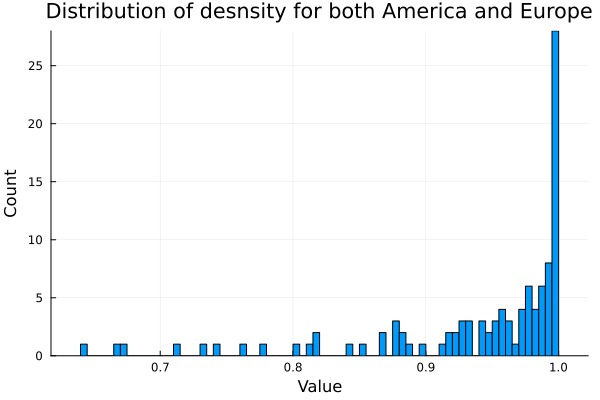

In [64]:
histogram(city_df.Value; 
    bins = 100,            # number of bins
    title = "Distribution of desnsity for both America and Europe",
    xlabel = "Value",
    ylabel = "Count",
    legend = false
)

#histogram(europe.Value; 
#    bins = 100,            # number of bins
#    title = "Distribution of desnsity for both America and Europe",
#    xlabel = "Value",
#    ylabel = "Count",
#    legend = false
#)
#histogram(america.Value; 
#    bins = 100,            # number of bins
#    title = "Distribution of desnsity for both America and Europe",
#    xlabel = "Value",
#    ylabel = "Count",
#    legend = false
#)

#CairoMakie.violin(city_df.continent,city_df.Value)

In [67]:
fg = @df city_df StatsPlots.violin(:continent, :Value;
    title = "Value by Continent",
    xlabel = "Continent",
    ylabel = "Value",
    legend = false,
    
)
savefig(fg,"violin_eu_am.svg")

"/home/adamkas/Julia/map_analyses/map_analyses/violin_eu_am.svg"

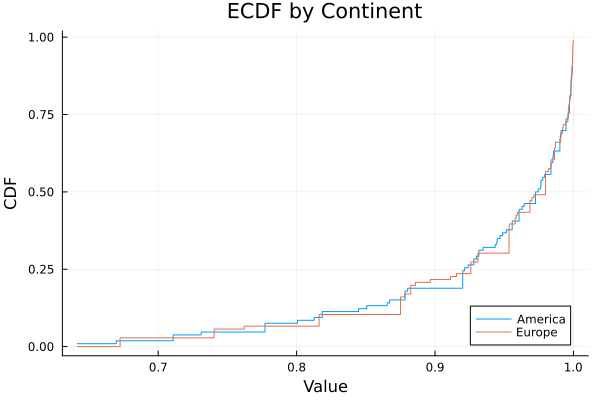

In [71]:
@df city_df StatsPlots.ecdfplot(:Value, group = :continent; 
    title = "ECDF by Continent",
    xlabel = "Value",
    ylabel = "CDF",
    legend = :bottomright
)